# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Thoriq Dhiya Aptaribowo
- Email: wisma277@gmail.com
- Id Dicoding:

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

### Menyiapkan data yang akan diguankan

## Data Understanding

===== Head =====


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2



===== Describe =====


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,NaN,NaN,3,NaN,3,NaN,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1043,NaN,961,NaN,NaN,606,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,735.500000,36.923810,0.169187,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000



===== Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int

EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC


===== Duplicates ======
0

===== Categorical Column ======
BusinessTravel : ['Travel_Frequently' 'Travel_Rarely' 'Non-Travel']
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Department : ['Human Resources' 'Research & Development' 'Sales']
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
EducationField : ['Other' 'Medical' 'Life Sciences' 'Marketing' 'Technical Degree'
 'Human Resources']
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Gender : ['Male' 'Female']
Gender
Male      882
Female    588
Name: count, dtype: int64
JobRole : ['Human Resources' 'Healthcare Representative' 'Research Scientist'
 'Sales Executive' 'Manager' 'Laboratory Technician' 'Research Director'
 'Manufacturing Director' 'Sales 

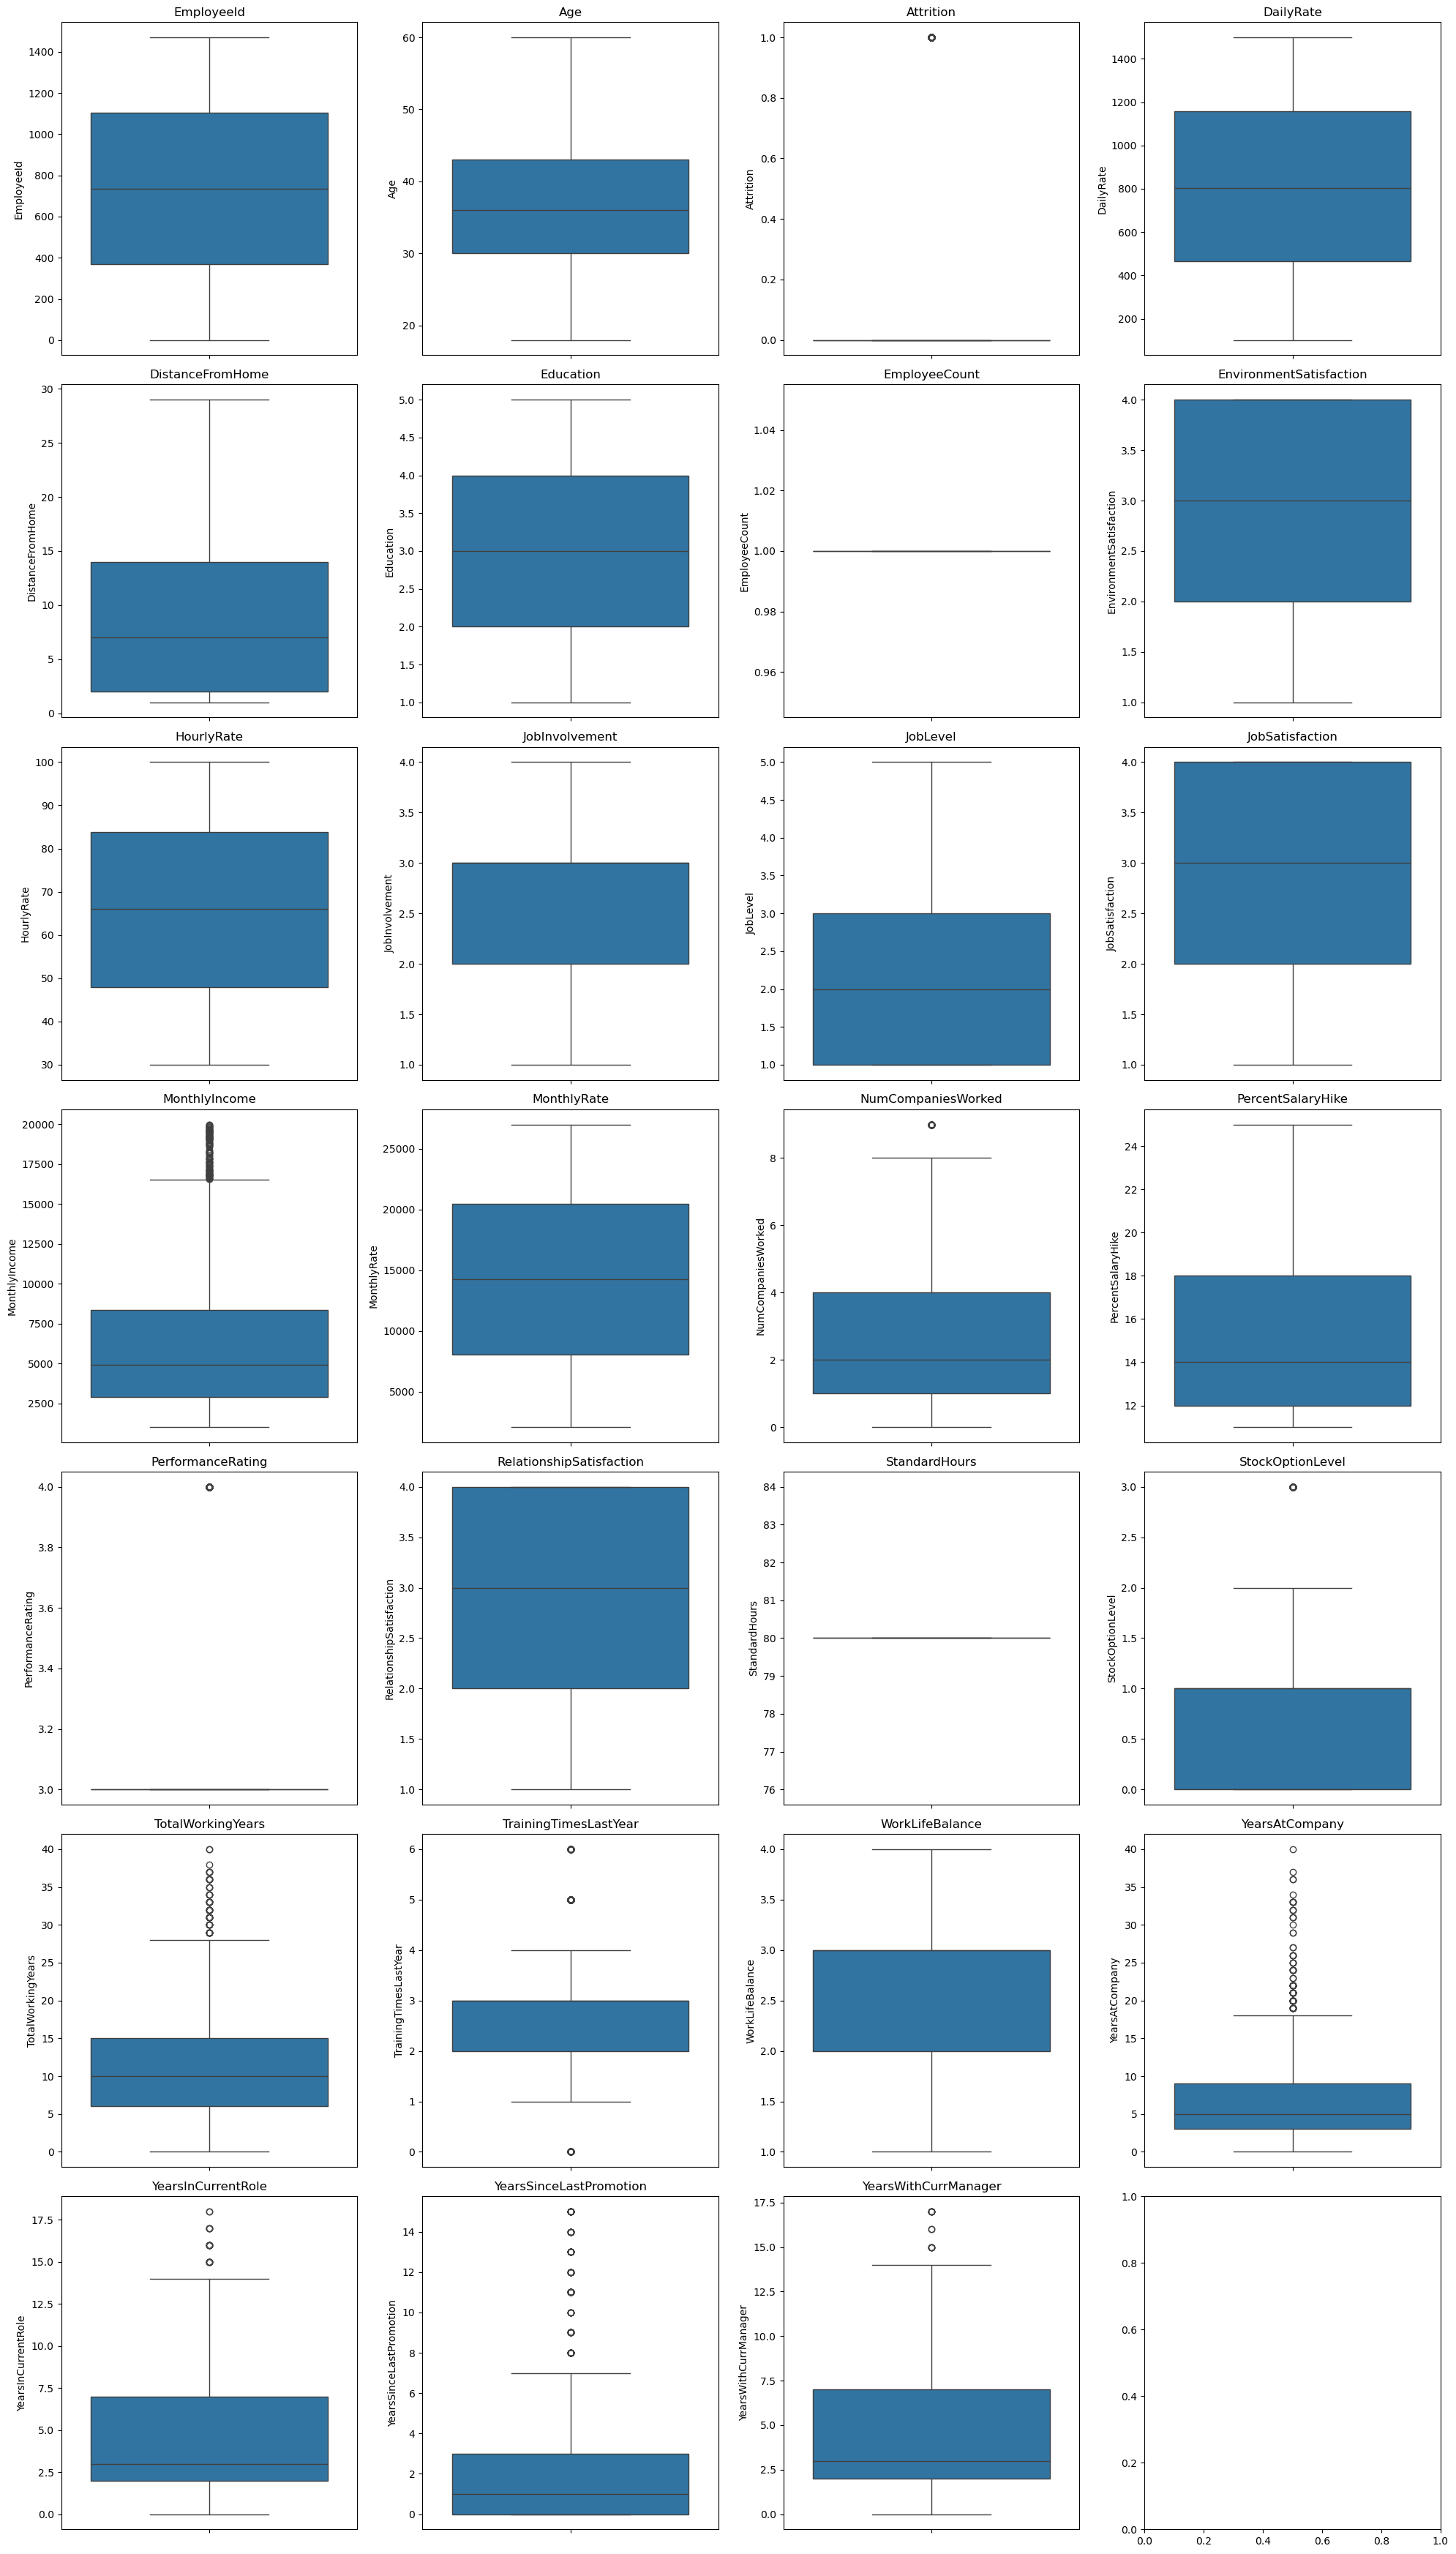

In [2]:
# Load and checking the data

df = pd.read_csv("employee_data.csv")

def data_exploration (df):
    print("===== Head =====")
    display(df.head())
    print()
    print("===== Describe =====")
    display(df.describe(include='all'))
    print()
    print("===== Info =====")
    print(df.info())
    print()
    print("===== Isnull =====")
    display(df.isnull().sum())
    print()
    print("===== Duplicates ======")
    print(df.duplicated().sum())
    print()
    print("===== Categorical Column ======")
    object_col = []
    for column in df.columns:
        if df[column].dtype == object and len(df[column].unique()) <= 30:
            object_col.append(column)
            print(f"{column} : {df[column].unique()}")
            print(df[column].value_counts())
            print("====================================")

def create_boxplot(df):
        num_var =df.select_dtypes(include=['int64', 'float64']).columns
        n_cols = 4
        n_rows = int(np.ceil(len(num_var) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
        axes = axes.flatten()
        for i, var in enumerate(num_var):
            sns.boxplot(y=df[var], ax=axes[i])
            axes[i].set_title(var)
        plt.tight_layout()
        plt.show()


data_exploration(df)
create_boxplot(df)

In [3]:
# Data cleaning
data = df.fillna(0)
data = data[['EmployeeId', 'MonthlyIncome', 'DailyRate','Department', 'EnvironmentSatisfaction',
            'JobSatisfaction', 'StockOptionLevel', 'WorkLifeBalance', 'NumCompaniesWorked', 
            'YearsInCurrentRole', 'PercentSalaryHike', 'YearsWithCurrManager', 'Attrition']]

data.to_csv('data.csv', index=False)
data_exploration(data)

===== Head =====


,EmployeeId,MonthlyIncome,DailyRate,Department,EnvironmentSatisfaction,JobSatisfaction,StockOptionLevel,WorkLifeBalance,NumCompaniesWorked,YearsInCurrentRole,PercentSalaryHike,YearsWithCurrManager,Attrition
0,1,2991,1444,Human Resources,4,2,1,3,0,2,11,2,0.0
1,2,4777,1141,Research & Development,1,2,0,1,5,0,15,0,1.0
2,3,2461,1323,Research & Development,1,3,3,4,9,0,12,7,1.0
3,4,13525,555,Sales,3,2,1,4,5,4,14,8,0.0
4,5,2001,1194,Research & Development,3,3,3,3,2,3,14,2,0.0



===== Describe =====


,EmployeeId,MonthlyIncome,DailyRate,Department,EnvironmentSatisfaction,JobSatisfaction,StockOptionLevel,WorkLifeBalance,NumCompaniesWorked,YearsInCurrentRole,PercentSalaryHike,YearsWithCurrManager,Attrition
count,1470.000000,1470.000000,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Research & Development,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,735.500000,6502.931293,802.485714,NaN,2.721769,2.728571,0.793878,2.761224,2.693197,4.229252,15.209524,4.123129,0.121769
std,424.496761,4707.956783,403.509100,NaN,1.093082,1.102846,0.852077,0.706476,2.498009,3.623137,3.659938,3.568136,0.327130
min,1.000000,1009.000000,102.000000,NaN,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,11.000000,0.000000,0.000000
25%,368.250000,2911.000000,465.000000,NaN,2.000000,2.000000,0.000000,2.000000,1.000000,2.000000,12.000000,2.000000,0.000000
50%,735.500000,4919.000000,802.000000,NaN,3.000000,3.000000,1.000000,3.000000,2.000000,3.000000,14.000000,3.000000,0.000000
75%,1102.750000,8379.000000,1157.000000,NaN,4.000000,4.000000,1.000000,3.000000,4.000000,7.000000,18.000000,7.000000,0.000000



===== Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeId               1470 non-null   int64  
 1   MonthlyIncome            1470 non-null   int64  
 2   DailyRate                1470 non-null   int64  
 3   Department               1470 non-null   object 
 4   EnvironmentSatisfaction  1470 non-null   int64  
 5   JobSatisfaction          1470 non-null   int64  
 6   StockOptionLevel         1470 non-null   int64  
 7   WorkLifeBalance          1470 non-null   int64  
 8   NumCompaniesWorked       1470 non-null   int64  
 9   YearsInCurrentRole       1470 non-null   int64  
 10  PercentSalaryHike        1470 non-null   int64  
 11  YearsWithCurrManager     1470 non-null   int64  
 12  Attrition                1470 non-null   float64
dtypes: float64(1), int64(11), object(1)
memory usage: 149.4+ KB


EmployeeId                 0
MonthlyIncome              0
DailyRate                  0
Department                 0
EnvironmentSatisfaction    0
JobSatisfaction            0
StockOptionLevel           0
WorkLifeBalance            0
NumCompaniesWorked         0
YearsInCurrentRole         0
PercentSalaryHike          0
YearsWithCurrManager       0
Attrition                  0
dtype: int64


===== Duplicates ======
0

===== Categorical Column ======
Department : ['Human Resources' 'Research & Development' 'Sales']
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [4]:
# Analysis: Income on attrition

rate_att=data.groupby(['MonthlyIncome','Attrition']).apply(lambda x:x['MonthlyIncome'].count()).reset_index(name='Counts')
rate_att['MonthlyIncome']=round(rate_att['MonthlyIncome'],-3)
rate_att=rate_att.groupby(['MonthlyIncome','Attrition']).apply(lambda x:x['MonthlyIncome'].count()).reset_index(name='Counts')
fig=px.line(rate_att,x='MonthlyIncome',y='Counts',color='Attrition',title='Monthly Income basis counts of People in an Organization')
fig.show()

/tmp/ipykernel_10769/1512361462.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rate_att=data.groupby(['MonthlyIncome','Attrition']).apply(lambda x:x['MonthlyIncome'].count()).reset_index(name='Counts')
/tmp/ipykernel_10769/1512361462.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rate_att=rate_att.groupby(['MonthlyIncome','Attrition']).apply(lambda x:x['MonthlyIncome'].count()).reset_index(name='Counts')


In [5]:
# Analysis: Departement of work on attrition

dept_att=data.groupby(['Department','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
fig=px.bar(dept_att,x='Department',y='Counts',color='Attrition',title='Department wise Counts of People in an Organization')
fig.show()

/tmp/ipykernel_10769/1092495919.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [6]:
# Analysis: Environment satisfaction on attrition

sats_att=data.groupby(['EnvironmentSatisfaction','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(sats_att,x='EnvironmentSatisfaction',y='Counts',color='Attrition',title='Environment Satisfaction level Counts of People in an Organization')

/tmp/ipykernel_10769/4268763004.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [7]:
# Analysis: Job Satisfaction on attrition

jsats_att=data.groupby(['JobSatisfaction','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(jsats_att,x='JobSatisfaction',y='Counts',color='Attrition',title='Job Satisfaction level Counts of People in an Organization')

/tmp/ipykernel_10769/3739634776.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [8]:
# Analysis: Company stock on attrition

stock_att=data.groupby(['StockOptionLevel','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.bar(stock_att,x='StockOptionLevel',y='Counts',color='Attrition',title='Stock facilities level wise People in an Organization')

/tmp/ipykernel_10769/2431345386.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [9]:
# Analysis: Work life balance on attrition

wlb_att=data.groupby(['WorkLifeBalance','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.bar(wlb_att,x='WorkLifeBalance',y='Counts',color='Attrition',title='Work Life Balance level Counts of People in an Organization')

/tmp/ipykernel_10769/1325789356.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [10]:
# Analysis: Work experience on attrition

ncwrd_att=data.groupby(['NumCompaniesWorked','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(ncwrd_att,x='NumCompaniesWorked',y='Counts',color='Attrition',title='Work Experience level Counts of People in an Organization')


/tmp/ipykernel_10769/2565846919.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [11]:
# Analysis: Work duration on attrition

yrscr_att=data.groupby(['YearsInCurrentRole','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(yrscr_att,x='YearsInCurrentRole',y='Counts',color='Attrition',title='Counts of People working for years in an Organization')

/tmp/ipykernel_10769/3991859741.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [12]:
# Analysis: Hike percentage on attrition

hike_att=data.groupby(['PercentSalaryHike','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(hike_att,x='PercentSalaryHike',y='Counts',color='Attrition',title='Count of Hike Percentages people receive in an Organization')

/tmp/ipykernel_10769/2641972354.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [13]:
# Analysis: Managers on attrition

man_att=data.groupby(['YearsWithCurrManager','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(man_att,x='YearsWithCurrManager',y='Counts',color='Attrition',title='Count of people spending years with a Manager in an Organization')

/tmp/ipykernel_10769/2488396020.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



## Data Preparation / Preprocessing

In [14]:
# Lable Encoding

le = LabelEncoder()

data_processed = data.copy()

cols = data_processed.select_dtypes(include=['object']).columns

for col in cols:
    if col == 'Attrition': 
        continue
    data_processed[col] = le.fit_transform(data_processed[col]) #type: ignore

data_processed['Attrition'] = le.fit_transform(data_processed['Attrition']) #type: ignore

<Axes: >

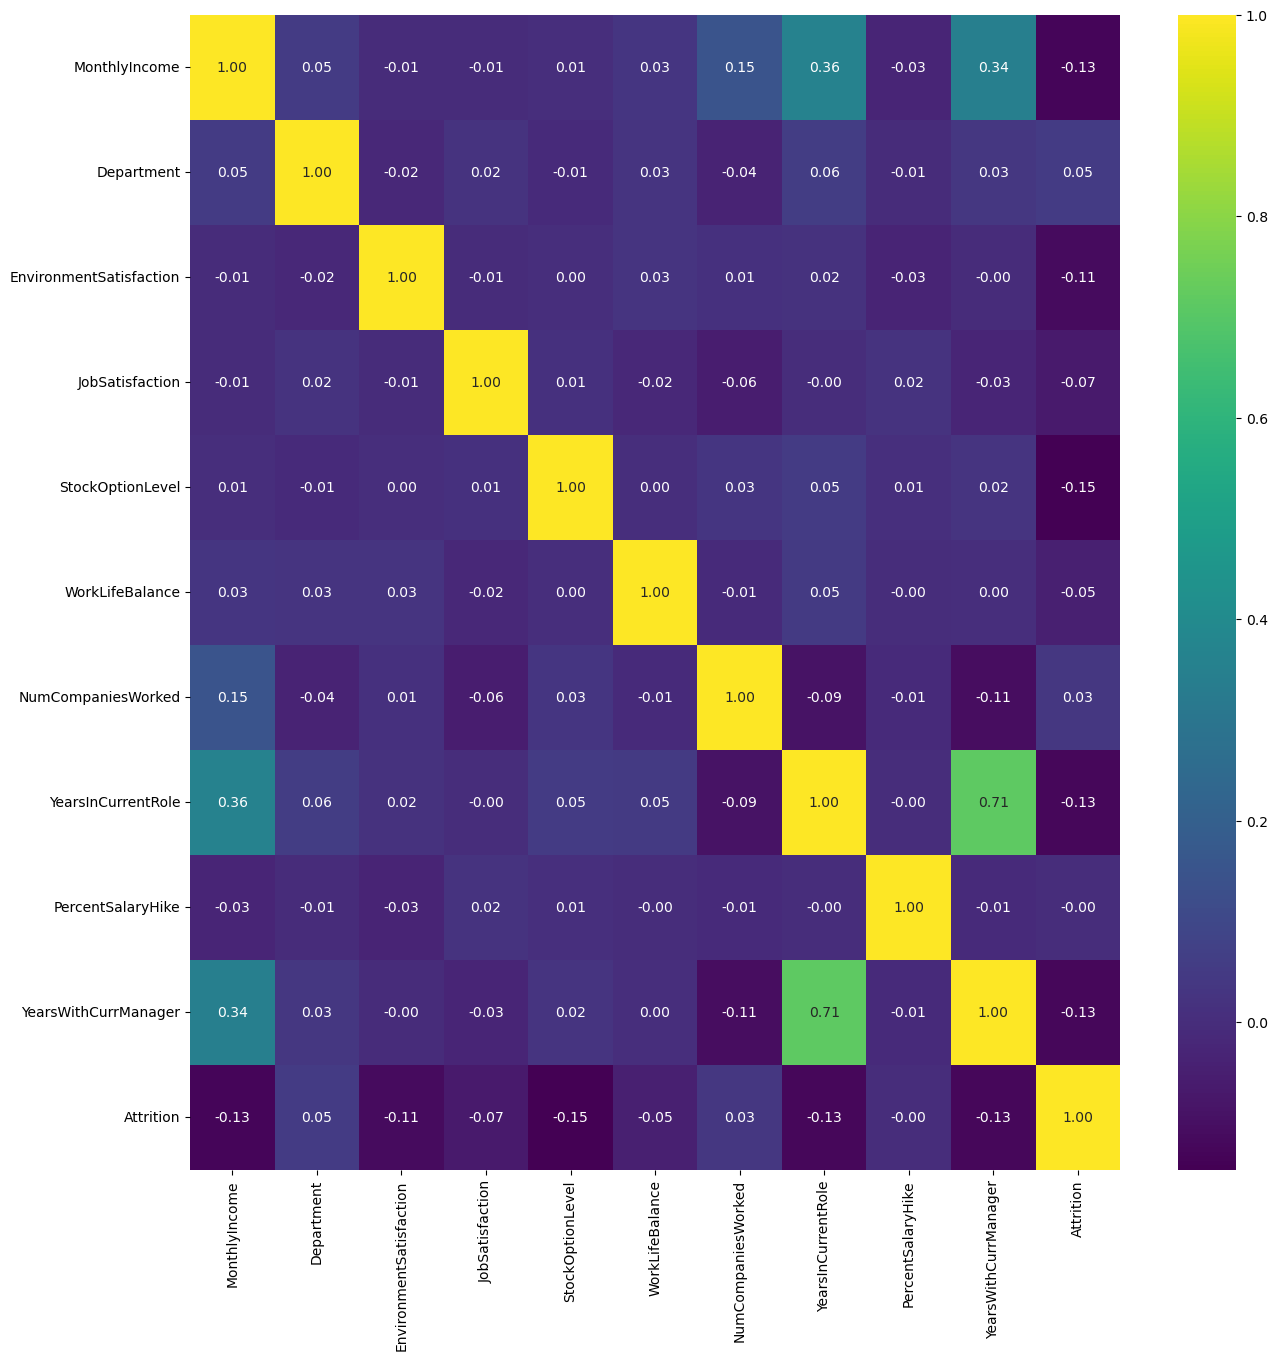

In [15]:
# Correlation matrix

data_model = data_processed.drop(columns=['EmployeeId', 'DailyRate'], axis=1)

plt.figure(figsize=(15,15))
sns.heatmap(data_model.corr(),annot=True,fmt='.2f',cmap='viridis')

In [16]:
# Train test split

X = data_model.drop('Attrition', axis=1)
y = data_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling

In [17]:
Model = RandomForestClassifier(n_estimators =100)
Model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Evaluation

In [18]:
# Model Performance
def evaluate(model):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("TRAINIG RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

    print("TESTING RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

evaluate(Model)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[1029    0]
 [   0  147]]
ACCURACY SCORE:
1.0000
CLASSIFICATION REPORT:
                0      1  accuracy  macro avg  weighted avg
precision     1.0    1.0       1.0        1.0           1.0
recall        1.0    1.0       1.0        1.0           1.0
f1-score      1.0    1.0       1.0        1.0           1.0
support    1029.0  147.0       1.0     1176.0        1176.0
TESTING RESULTS: 
CONFUSION MATRIX:
[[260   2]
 [ 32   0]]
ACCURACY SCORE:
0.8844
CLASSIFICATION REPORT:
                    0     1  accuracy   macro avg  weighted avg
precision    0.890411   0.0  0.884354    0.445205      0.793495
recall       0.992366   0.0  0.884354    0.496183      0.884354
f1-score     0.938628   0.0  0.884354    0.469314      0.836465
support    262.000000  32.0  0.884354  294.000000    294.000000


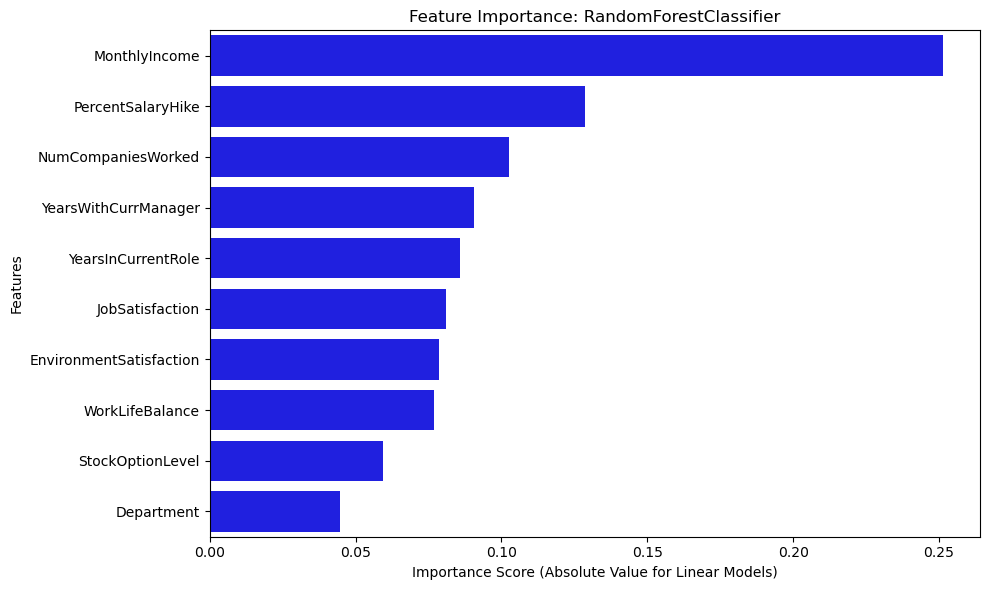

In [19]:
# Feature Importance

importance = Model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', color='blue', legend=False)
plt.title(f'Feature Importance: {type(Model).__name__}')
plt.xlabel('Importance Score (Absolute Value for Linear Models)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [20]:
# Dump Model
import joblib

joblib.dump(Model, 'model.pkl')
joblib.dump(le, 'encoder.pkl')

['encoder.pkl']